In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

In [3]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [4]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


In [5]:
print("Number of training images:", len(X_train))
print("Number of testing images:", len(X_test))

print("Image size:", X_train[0].shape)

print("First image label:", y_train[0])

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Number of training images: 60000
Number of testing images: 10000
Image size: (28, 28)
First image label: 5
Minimum pixel value: 0
Maximum pixel value: 255


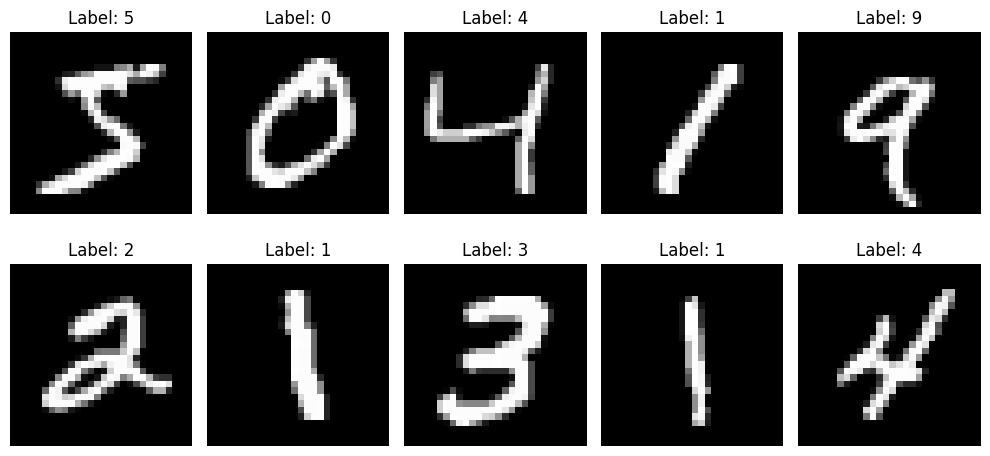

In [6]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
unique, counts = np.unique(y_train, return_counts=True)

print("Digit distribution:")

for digit, count in zip(unique, counts):
    print("Digit", digit, ":", count)

Digit distribution:
Digit 0 : 5923
Digit 1 : 6742
Digit 2 : 5958
Digit 3 : 6131
Digit 4 : 5842
Digit 5 : 5421
Digit 6 : 5918
Digit 7 : 6265
Digit 8 : 5851
Digit 9 : 5949


In [8]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("New minimum pixel value:", X_train.min())
print("New maximum pixel value:", X_train.max())

New minimum pixel value: 0.0
New maximum pixel value: 1.0


In [9]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9191 - loss: 0.2858 - val_accuracy: 0.9553 - val_loss: 0.1620
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9635 - loss: 0.1273 - val_accuracy: 0.9640 - val_loss: 0.1208
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9738 - loss: 0.0879 - val_accuracy: 0.9650 - val_loss: 0.1177
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9799 - loss: 0.0671 - val_accuracy: 0.9712 - val_loss: 0.0968
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9845 - loss: 0.0517 - val_accuracy: 0.9720 - val_loss: 0.0933
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9881 - loss: 0.0398 - val_accuracy: 0.9740 - val_loss: 0.0883
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9908 - loss: 0.0307 - val_accuracy: 0.9730 - val_loss: 0.1004
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9925 - loss: 0.0249 -

In [12]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy Percentage:", test_accuracy * 100, "%")

Test Loss: 0.0889134481549263
Test Accuracy: 0.9761000275611877
Test Accuracy Percentage: 97.61000275611877 %


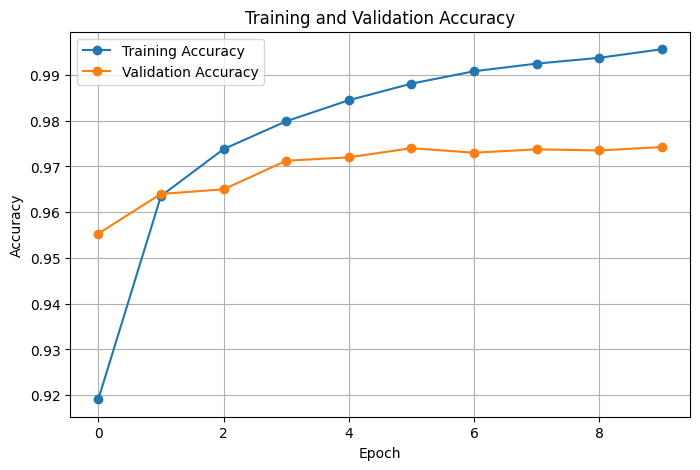

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

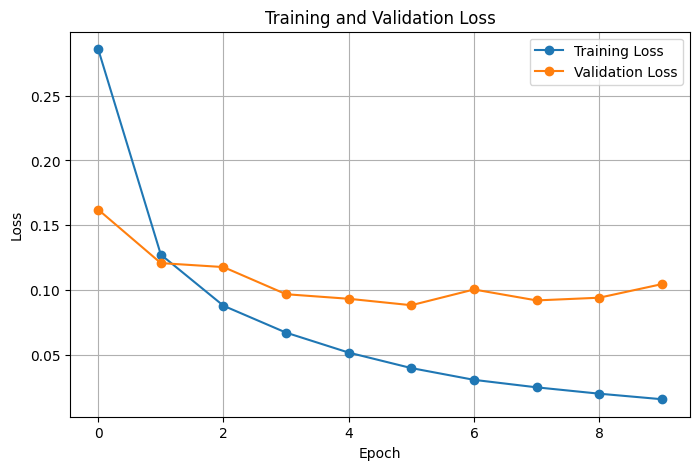

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], marker='o', label='Training Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

print("First 10 predicted labels:")
print(predicted_labels[:10])

print("First 10 actual labels:")
print(y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
First 10 predicted labels:
[7 2 1 0 4 1 4 9 8 9]
First 10 actual labels:
[7 2 1 0 4 1 4 9 5 9]


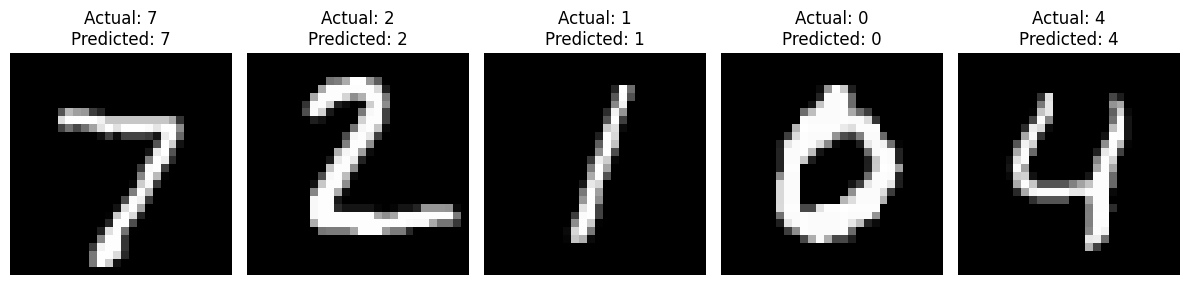

In [16]:
plt.figure(figsize=(12, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    plt.imshow(X_test[i], cmap='gray')

    actual = y_test[i]
    predicted = predicted_labels[i]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
print("5 Image Prediction Results")
print("-" * 35)

for i in range(5):
    print(
        f"Image {i+1}: "
        f"Actual = {y_test[i]}, "
        f"Predicted = {predicted_labels[i]}"
    )

5 Image Prediction Results
-----------------------------------
Image 1: Actual = 7, Predicted = 7
Image 2: Actual = 2, Predicted = 2
Image 3: Actual = 1, Predicted = 1
Image 4: Actual = 0, Predicted = 0
Image 5: Actual = 4, Predicted = 4


In [18]:
experiment_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

experiment_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
experiment_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
experiment_history = experiment_model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9273 - loss: 0.2532 - val_accuracy: 0.9602 - val_loss: 0.1324
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9686 - loss: 0.1067 - val_accuracy: 0.9687 - val_loss: 0.1028
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9792 - loss: 0.0696 - val_accuracy: 0.9744 - val_loss: 0.0822
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9843 - loss: 0.0505 - val_accuracy: 0.9762 - val_loss: 0.0780
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9889 - loss: 0.0367 - val_accuracy: 0.9766 - val_loss: 0.0797
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9922 - loss: 0.0270 - val_accuracy: 0.9772 - val_loss: 0.0793
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9934 - loss: 0.0212 - val_accuracy: 0.9783 - val_loss: 0.0767
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9949 - loss: 0.01

In [21]:
experiment_loss, experiment_accuracy = experiment_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Experiment Test Loss:", experiment_loss)
print("Experiment Test Accuracy:", experiment_accuracy)
print(
    "Experiment Test Accuracy Percentage:",
    experiment_accuracy * 100,
    "%"
)

Experiment Test Loss: 0.09642260521650314
Experiment Test Accuracy: 0.9753000140190125
Experiment Test Accuracy Percentage: 97.53000140190125 %


In [22]:
print("Model Comparison")
print("=" * 45)

print(
    f"Original Model - 128 neurons: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Experiment Model - 256 neurons: "
    f"{experiment_accuracy * 100:.2f}%"
)

Model Comparison
Original Model - 128 neurons: 97.61%
Experiment Model - 256 neurons: 97.53%


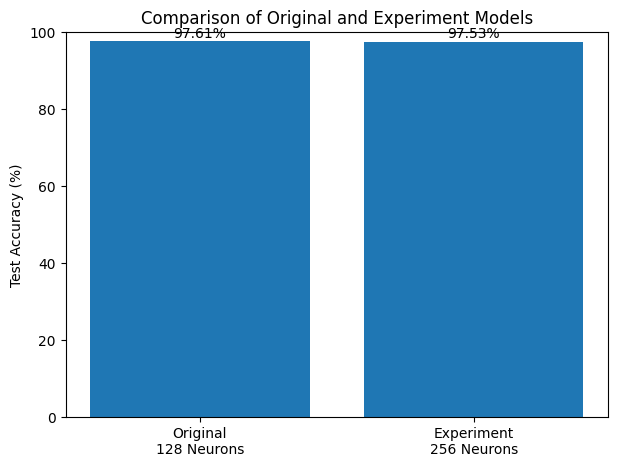

In [23]:
models = ['Original\n128 Neurons', 'Experiment\n256 Neurons']
accuracies = [test_accuracy * 100, experiment_accuracy * 100]

plt.figure(figsize=(7, 5))

plt.bar(models, accuracies)

plt.ylabel('Test Accuracy (%)')
plt.title('Comparison of Original and Experiment Models')
plt.ylim(0, 100)

for i, value in enumerate(accuracies):
    plt.text(i, value + 1, f'{value:.2f}%', ha='center')

plt.show()

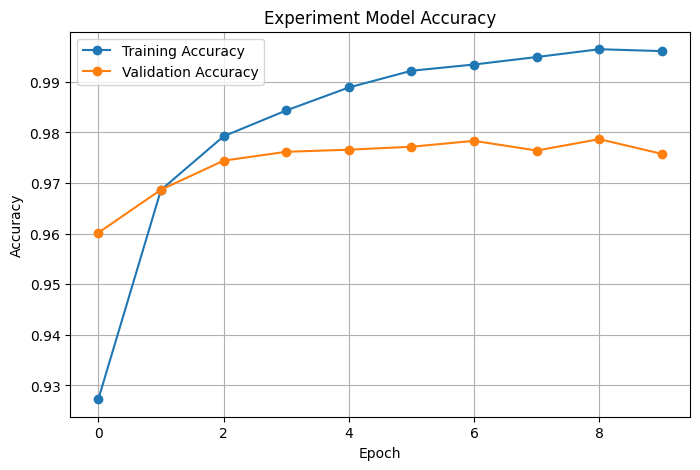

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    experiment_history.history['accuracy'],
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    experiment_history.history['val_accuracy'],
    marker='o',
    label='Validation Accuracy'
)

plt.title('Experiment Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
print("FINAL RESULTS")
print("=" * 50)

print(f"Original Model Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Experiment Model Test Accuracy: {experiment_accuracy * 100:.2f}%")

print("\n5 Image Predictions:")

for i in range(5):
    print(
        f"Image {i+1}: "
        f"Actual = {y_test[i]}, "
        f"Predicted = {predicted_labels[i]}"
    )

FINAL RESULTS
Original Model Test Accuracy: 97.61%
Experiment Model Test Accuracy: 97.53%

5 Image Predictions:
Image 1: Actual = 7, Predicted = 7
Image 2: Actual = 2, Predicted = 2
Image 3: Actual = 1, Predicted = 1
Image 4: Actual = 0, Predicted = 0
Image 5: Actual = 4, Predicted = 4
